In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
nltk.download("stopwords")

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ANUSHA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
df = pd.read_csv("Spamdataset.csv")

df.head()

,emails,label
0,From spamassassin-talk-admin@lists.sourceforge...,0
1,From rssfeeds@jmason.org Tue Oct 1 10:37:37 ...,0
2,From ilug-admin@linux.ie Tue Oct 8 12:26:48 ...,0
3,From fork-admin@xent.com Mon Sep 30 13:52:45 ...,0
4,From fork-admin@xent.com Thu Aug 29 11:03:51 ...,0


In [3]:
df.shape

(5797, 2)

In [4]:
df.dtypes

emails    object
label      int64
dtype: object

In [5]:
df.isnull().sum()

emails    0
label     0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df = df.drop_duplicates()

In [8]:
df["label"].value_counts()

label
0    3900
1    1897
Name: count, dtype: int64

In [9]:
df["label"].value_counts(normalize=True)*100

label
0    67.276177
1    32.723823
Name: proportion, dtype: float64

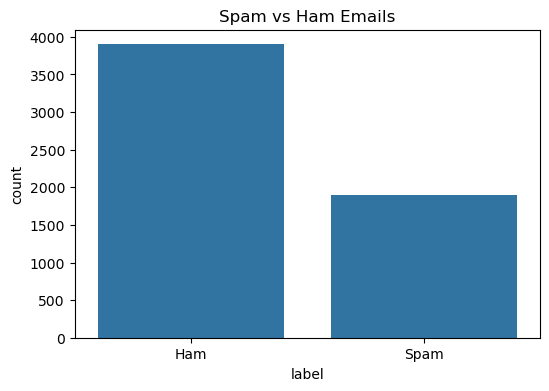

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(x="label",data=df)

plt.xticks([0,1],["Ham","Spam"])

plt.title("Spam vs Ham Emails")

plt.savefig("spam_vs_ham.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
stop_words = set(stopwords.words("english"))

In [12]:
def clean_email(text):

    text = text.lower()

    text = re.sub(r'http\S+',' ',text)

    text = re.sub(r'\S+@\S+',' ',text)

    text = re.sub(r'[^a-zA-Z ]',' ',text)

    words = text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [13]:
df["clean_email"] = df["emails"].apply(clean_email)

TF-IDF (Term Frequency–Inverse Document Frequency) converts text into numerical vectors by measuring how important a word is within an email compared to all emails in the dataset. Words that appear frequently in a specific email but not across many emails receive higher weights, making them more useful for classification.

In [14]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["clean_email"])

y = df["label"]

In [15]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
nb = MultinomialNB()

nb.fit(X_train,y_train)

pred_nb = nb.predict(X_test)

In [17]:
print("Accuracy:",accuracy_score(y_test,pred_nb))

print(classification_report(y_test,pred_nb))

Accuracy: 0.975
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       772
           1       0.99      0.93      0.96       388

    accuracy                           0.97      1160
   macro avg       0.98      0.96      0.97      1160
weighted avg       0.98      0.97      0.97      1160



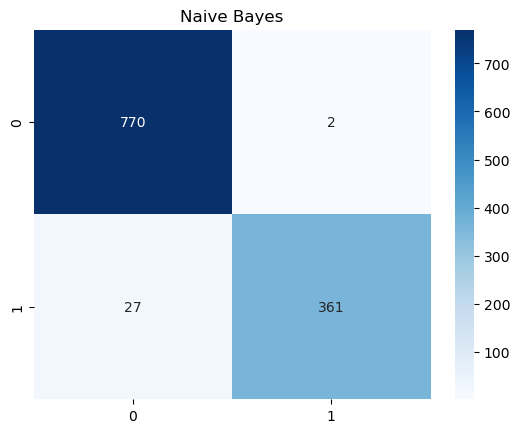

In [18]:
sns.heatmap(
    confusion_matrix(y_test,pred_nb),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Naive Bayes")

plt.savefig("naive_bayes.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

In [20]:
print("Accuracy:",accuracy_score(y_test,pred_lr))

print(classification_report(y_test,pred_lr))

Accuracy: 0.978448275862069
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       772
           1       1.00      0.94      0.97       388

    accuracy                           0.98      1160
   macro avg       0.98      0.97      0.98      1160
weighted avg       0.98      0.98      0.98      1160



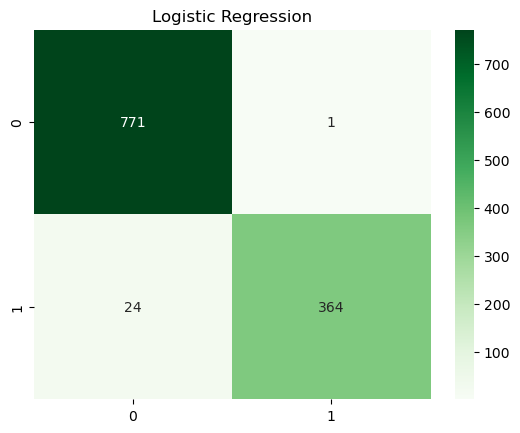

In [21]:
sns.heatmap(
    confusion_matrix(y_test,pred_lr),
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Logistic Regression")

plt.savefig("logistic_regression.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
comparison = pd.DataFrame({

"Model":[
"Naive Bayes",
"Logistic Regression"
],

"Accuracy":[
accuracy_score(y_test,pred_nb),
accuracy_score(y_test,pred_lr)
]

})

comparison

,Model,Accuracy
0,Naive Bayes,0.975000
1,Logistic Regression,0.978448


In [23]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [24]:
from wordcloud import WordCloud

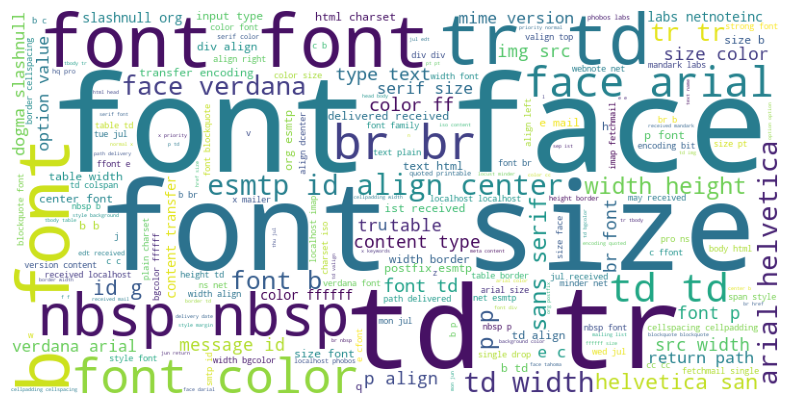

In [25]:
spam_text = " ".join(
    df[df["label"]==1]["clean_email"]
)

wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
)

plt.figure(figsize=(10,5))

plt.imshow(wc.generate(spam_text))

plt.axis("off")

plt.show()

In [ ]:
ham_text = " ".join(
    df[df["label"]==0]["clean_email"]
)

plt.figure(figsize=(10,5))

plt.imshow(
    WordCloud(
        background_color="white"
    ).generate(ham_text)
)

plt.axis("off")

plt.show()

Why is Recall important in spam detection?

Recall is important because it measures how many actual spam emails are correctly identified by the model. A high recall reduces the number of spam emails that reach a user's inbox. Missing spam emails (false negatives) can expose users to phishing attacks, scams, malware, and unwanted advertisements. Therefore, maximizing recall helps improve email security and user experience.